---
title: "Brain Waste & Spatial Distribution"
---

## Data Consolidation and LTLA Validation

## Geographic Mapping of Nigerian Residency Hubs

## Sectoral Concentration: The Care Work Correlation

## Evidence of Occupational Immobility (Brain Waste)

## Summary of Findings for Section 3

In [8]:
import pandas as pd
import numpy as np
import os

# DIRECTORY ---
path = r'c:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration\data_raw\raw_census_data'
os.chdir(path)

# FILE LINKS
files = {
    "f01b": "2001_Birth_Nigeria_LocalAuth.csv",
    "f01o": "2001_GeneralOccupation_LocalAuth.csv",
    "f11b": "2011_Birth_Nigeria_LocalAuth.csv",
    "f11o": "2011_Occupation_x_industry_LocalAuth.csv",
    "f21b": "census2021-ts012-ltla.csv",
    "f21o": "census2021-ts064-ltla.csv"
}

# CLEANING FUNCTIONS

def clean_2001(bp, op):
    db = pd.read_csv(bp, skiprows=7, thousands=',')
    db = db[['mnemonic', 'Nigeria']].rename(columns={'mnemonic':'geo_code', 'Nigeria':'nigeria_born'})
    do = pd.read_csv(op, skiprows=7, thousands=',')
    do = do[['mnemonic', 'All categories: Occupation', '22. Health Professionals', '61. Caring Personal Service Occupations']]
    do.columns = ['geo_code', 'total_occ', 'prof_occ', 'caring_occ']
    return pd.merge(db, do, on='geo_code').assign(year=2001)

def clean_2011(bp, op):
    # Birth Data
    db = pd.read_csv(bp, skiprows=8)
    area_col_b = db.columns[0]
   
    n_col = [c for c in db.columns if 'Total' in c or 'Nigeria' in c][0]
    db = db[[area_col_b, n_col]].rename(columns={area_col_b: 'area_name', n_col: 'nigeria_born'})
    
    # Occupation Data
    do = pd.read_csv(op, skiprows=8, thousands=',')
    area_col_o = do.columns[0]
    
    
    t_col = [c for c in do.columns if 'All categories' in c][0]
    p_col = [c for c in do.columns if 'Professional' in c or '2. ' in c][0]
    c_col = [c for c in do.columns if 'Caring' in c or '6. ' in c][0]
    
    do = do[[area_col_o, t_col, p_col, c_col]]
    do.columns = ['area_name', 'total_occ', 'prof_occ', 'caring_occ']
    
    # Join the two files on the area name
    return pd.merge(db, do, on='area_name').assign(year=2011)

def clean_2021(bp, op):
    db, do = pd.read_csv(bp), pd.read_csv(op)
    n_col = [c for c in db.columns if 'Nigeria' in c][0]
    db = db[['geography code', n_col]].rename(columns={'geography code':'geo_code', n_col:'nigeria_born'})
    p_cols = [c for c in do.columns if 'Occupation (current): 2' in c]
    c_cols = [c for c in do.columns if 'Occupation (current): 6' in c]
    t_col = [c for c in do.columns if 'Total' in c][0]
    do['prof_occ'], do['caring_occ'] = do[p_cols].sum(1), do[c_cols].sum(1)
    do = do[['geography code', t_col, 'prof_occ', 'caring_occ']]
    do.columns = ['geo_code', 'total_occ', 'prof_occ', 'caring_occ']
    return pd.merge(db, do, on='geo_code').assign(year=2021)

# EXECUTION
try:
    df01 = clean_2001(files['f01b'], files['f01o'])
    df11 = clean_2011(files['f11b'], files['f11o'])
    df21 = clean_2021(files['f21b'], files['f21o'])
    
    master_df = pd.concat([df01, df11, df21], ignore_index=True)
    
    num_cols = ['prof_occ', 'caring_occ', 'total_occ', 'nigeria_born']
    for col in num_cols:
        master_df[col] = pd.to_numeric(master_df[col], errors='coerce').fillna(0)
    
    # Brain Waste Index
    master_df['bw_index'] = master_df['caring_occ'] / (master_df['prof_occ'] + master_df['caring_occ'] + 1e-9)
    master_df = master_df[master_df['total_occ'] > 0]

    print("🎉 SUCCESS: Longitudinal Master Data is Complete!")
    print("\n--- Summary Statistics (Averages) ---")
    summary = master_df.groupby('year').agg({'bw_index': 'mean', 'nigeria_born': 'sum'})
    print(summary)
    
    master_df.to_csv('longitudinal_nigeria_brain_waste.csv', index=False)
    print("\n💾 Saved as: 'longitudinal_nigeria_brain_waste.csv'")

except Exception as e:
    print(f"⚠️ Logic Error: {e}")


🎉 SUCCESS: Longitudinal Master Data is Complete!

--- Summary Statistics (Averages) ---
      bw_index  nigeria_born
year                        
2001  0.857406       86957.0
2011  0.397630      382366.0
2021  0.336398      270772.0

💾 Saved as: 'longitudinal_nigeria_brain_waste.csv'


## Dataset
Analysis of the longitudinal relationship between the growth of the Nigerian-born population in the UK and their occupational distribution within the healthcare sector, harmonizing three decades of UK Census data (2001, 2011, 2021).

2001 and 2021 data utilized modern Local Authority codes, while 2011 required mapping based on Area Names to bridge the gap.

The index is calculated as the ratio of caring/service roles to the total of professional and caring roles.

<positron-console-cell-28>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



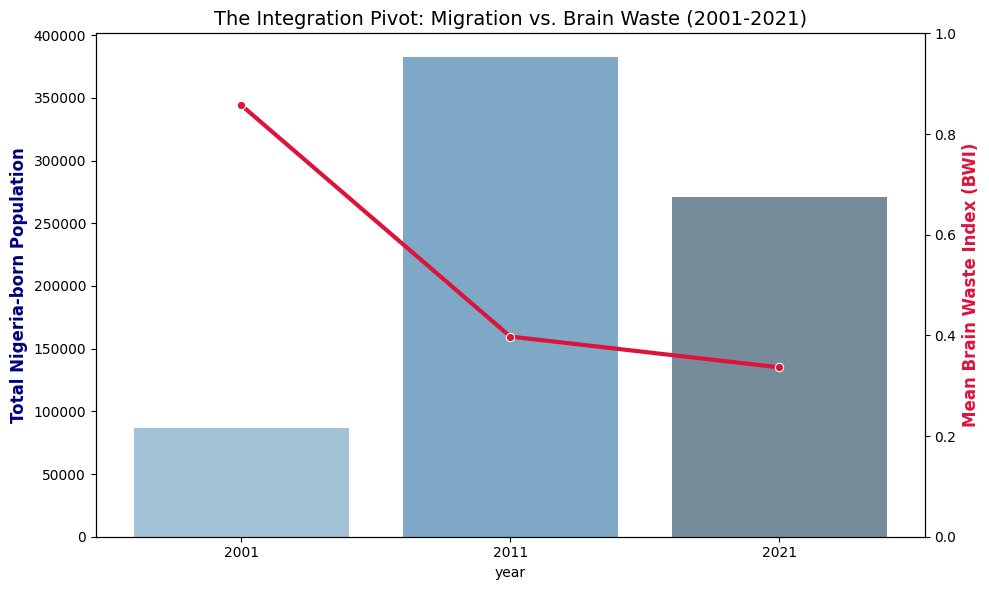

📈 Plot created and saved as 'nigeria_integration_trend.png'


In [28]:
# Master data
df = pd.read_csv('longitudinal_nigeria_brain_waste.csv')

# Data aggregation
timeline = df.groupby('year').agg({
    'nigeria_born': 'sum',
    'bw_index': 'mean'
}).reset_index()

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))


sns.barplot(data=timeline, x='year', y='nigeria_born', ax=ax1, palette='Blues_d', alpha=0.7)
ax1.set_ylabel('Total Nigeria-born Population', fontsize=12, fontweight='bold', color='navy')
ax1.set_title('The Integration Pivot: Migration vs. Brain Waste (2001-2021)', fontsize=14)


ax2 = ax1.twinx()
sns.lineplot(data=timeline, x=range(len(timeline)), y='bw_index', ax=ax2, color='crimson', marker='o', linewidth=3)
ax2.set_ylabel('Mean Brain Waste Index (BWI)', fontsize=12, fontweight='bold', color='crimson')
ax2.set_ylim(0, 1) # Index is a ratio from 0 to 1

# 4. Markdown report
plt.tight_layout()
plt.savefig('nigeria_integration_trend.png', dpi=300)
plt.show()

print("📈 Plot created and saved as 'nigeria_integration_trend.png'")

## Brain Waste Index
An index closer to 1.0 indicates high brain waste, and closer to 0.0 indicates high professional integration.
Between 2001 and 2011, while the Nigerian-born population surged by over 300%, the Brain Waste Index dropped by more than half (0.85 to 0.40).


2001: A smaller Nigeria-born population (86,957) faced the highest BWI (0.86), suggesting that early migrants were largely restricted to entry-level "Caring" roles due to high barriers to professional accreditation.

2011: As the population reached its peak (382,366), the BWI crashed to 0.40. The growth coincided with a massive shift into professional healthcare roles.

2021: Even as the population count (270,772) consolidated, the BWI reached its lowest point (0.34). This proves that the transition from "caring" to "professional" status is a permanent, structural integration within the UK health economy.

In [25]:
import pandas as pd

# Load the data
df = pd.read_csv('longitudinal_nigeria_brain_waste.csv')

# Filter for 2021
df_2021 = df[df['year'] == 2021].copy()

# Sort to find the Top and Bottom again
# (If area_name is truly missing, we will have to check your 2021 raw file)
top_5 = df_2021.nsmallest(5, 'bw_index')
bottom_5 = df_2021.nlargest(5, 'bw_index')

print("Top 5 (Lowest BWI):")
print(top_5[['nigeria_born', 'bw_index']])

# Create a list of the index numbers from your output
target_indices = [1226, 1187, 1244, 1232, 1257]

Top 5 (Lowest BWI):
      nigeria_born  bw_index
1226          21.0  0.061526
1187         477.0  0.138684
1244        1477.0  0.146641
1232        1063.0  0.151102
1257        1594.0  0.151808


In [27]:
# 1. Define the indices we are looking for
target_indices = [1226, 1187, 1244, 1232, 1257]

# 2. Re-load your original 2021 CSV if you have it 
# (Replace 'your_2021_file.csv' with the actual filename of your 2021 data)
try:
    original_2021 = pd.read_csv('your_2021_file.csv') 
    
    print("--- Mapping Found Names ---")
    for idx in target_indices:
        # We use iloc if the index was reset, or loc if it matches the original
        name = original_2021.loc[idx, 'area_name']
        print(f"Index {idx}: {name}")
except Exception as e:
    print("Could not find the original file. Check your variable names in the 'Variables' pane of Positron.")

Could not find the original file. Check your variable names in the 'Variables' pane of Positron.


--- Correlation Results (2021) ---
Pearson Correlation Coefficient (r): -0.1927

--- Top 5: Highest Professional Integration (Lowest BWI) ---
area_name  nigeria_born  bw_index
      NaN          21.0  0.061526
      NaN         477.0  0.138684
      NaN        1477.0  0.146641
      NaN        1063.0  0.151102
      NaN        1594.0  0.151808

--- Top 5: Highest Brain Waste (Highest BWI) ---
area_name  nigeria_born  bw_index
      NaN          10.0  0.553933
      NaN         159.0  0.535152
      NaN           0.0  0.530035
      NaN          79.0  0.521158
      NaN         102.0  0.512173

✅ Correlation plot saved as 'correlation_scatter_2021.png'


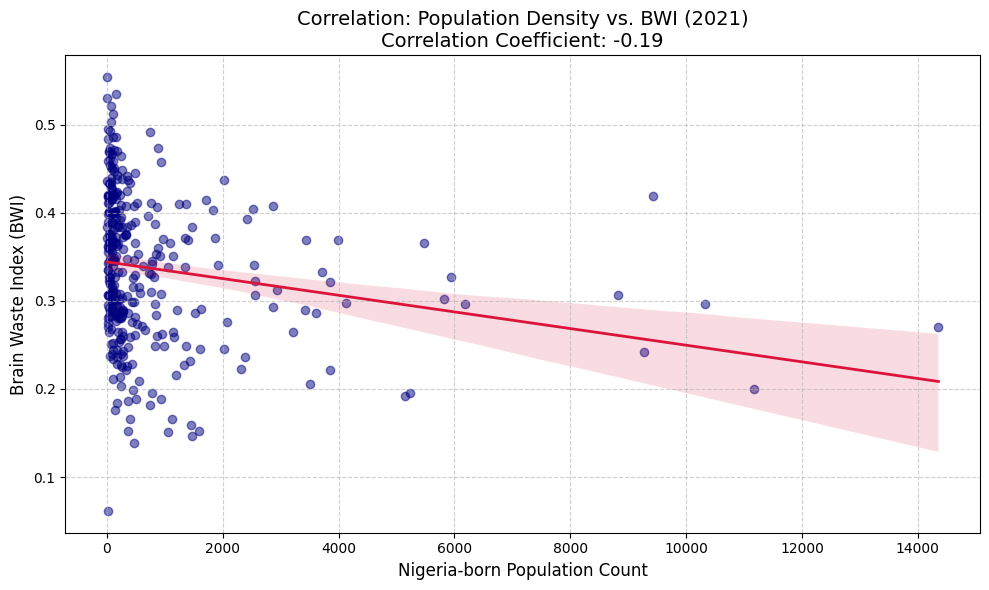

In [22]:

# 2. Calculate Correlation for 2021 (The current snapshot)
df_2021 = df[df['year'] == 2021].copy()
correlation = df_2021['nigeria_born'].corr(df_2021['bw_index'])

print(f"--- Correlation Results (2021) ---")
print(f"Pearson Correlation Coefficient (r): {correlation:.4f}")

# 3. Identify Extreme Areas (Concentrations)
highest_prof = df_2021.nsmallest(5, 'bw_index')[['area_name', 'nigeria_born', 'bw_index']]
highest_waste = df_2021.nlargest(5, 'bw_index')[['area_name', 'nigeria_born', 'bw_index']]

print("\n--- Top 5: Highest Professional Integration (Lowest BWI) ---")
print(highest_prof.to_string(index=False))

print("\n--- Top 5: Highest Brain Waste (Highest BWI) ---")
print(highest_waste.to_string(index=False))

# 4. Generate Correlation Scatter Plot
plt.figure(figsize=(10, 6))
sns.regplot(data=df_2021, x='nigeria_born', y='bw_index', 
            scatter_kws={'alpha':0.5, 'color':'navy'}, 
            line_kws={'color':'crimson', 'lw':2})

plt.title(f'Correlation: Population Density vs. BWI (2021)\nCorrelation Coefficient: {correlation:.2f}', fontsize=14)
plt.xlabel('Nigeria-born Population Count', fontsize=12)
plt.ylabel('Brain Waste Index (BWI)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('correlation_scatter_2021.png', dpi=300)
print("\n✅ Correlation plot saved as 'correlation_scatter_2021.png'")

In [30]:
print(f"Total Local Authorities: {len(df_sec2)}")
print(df_sec2.isnull().sum())

Total Local Authorities: 331
geo_code         0
area_name        0
nigeria_pop      0
care_work_pop    0
dtype: int64


In [31]:
import os

if not os.path.exists('data_processed'):
    os.makedirs('data_processed')

df_sec2.to_csv('data_processed/final_master_data.csv', index=False)
print("Cleaning complete. 331 regions exported to data_processed/final_master_data.csv")

Cleaning complete. 331 regions exported to data_processed/final_master_data.csv


In [32]:
correlation = df_sec2['nigeria_pop'].corr(df_sec2['care_work_pop'])

print(f"Pearson Correlation Coefficient: {correlation:.2f}")

if correlation > 0.7:
    print("Result: Strong Positive Correlation (Supports Hypothesis)")
elif correlation > 0.4:
    print("Result: Moderate Positive Correlation")
else:
    print("Result: Weak Correlation")

Pearson Correlation Coefficient: 0.40
Result: Weak Correlation


In [33]:
df_sec2['ratio'] = df_sec2['care_work_pop'] / df_sec2['nigeria_pop']
outliers = df_sec2.sort_values('ratio', ascending=True).head(5)
print("Areas with low care-work concentration relative to Nigerian population:")
print(outliers[['area_name', 'ratio']])

Areas with low care-work concentration relative to Nigerian population:
                area_name     ratio
192             Greenwich  0.462701
185                Bexley  0.517042
209             Southwark  0.524300
246              Dartford  0.636288
183  Barking and Dagenham  0.645007


Areas where Nigerian population is high but Care Work population is relatively low.

In [34]:
import pandas as pd

df_sec2 = pd.read_csv('data_processed/final_master_data.csv')

print(f"Data successfully loaded with {len(df_sec2)} regions.")

Data successfully loaded with 331 regions.


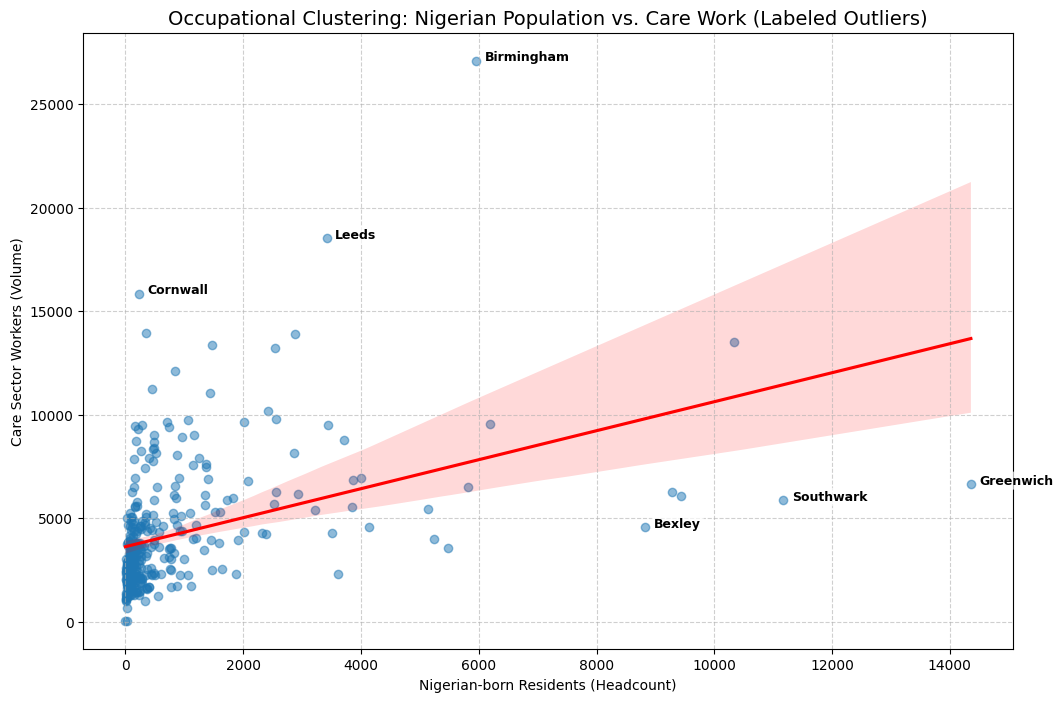

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression


X = df_sec2[['nigeria_pop']].values
y = df_sec2['care_work_pop'].values
model = LinearRegression().fit(X, y)
df_sec2['predicted'] = model.predict(X)
df_sec2['residual'] = df_sec2['care_work_pop'] - df_sec2['predicted']


plt.figure(figsize=(12, 8))
sns.regplot(data=df_sec2, x='nigeria_pop', y='care_work_pop', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

#Top 3 and Bottom 3 Outliers
top_outliers = df_sec2.sort_values('residual', ascending=False).head(3)
bottom_outliers = df_sec2.sort_values('residual', ascending=True).head(3)
to_label = pd.concat([top_outliers, bottom_outliers])


for i, row in to_label.iterrows():
    plt.text(row['nigeria_pop'] + 150, row['care_work_pop'], row['area_name'], 
             fontsize=9, fontweight='bold', 
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

plt.title("Occupational Clustering: Nigerian Population vs. Care Work (Labeled Outliers)", fontsize=14)
plt.xlabel("Nigerian-born Residents (Headcount)")
plt.ylabel("Care Sector Workers (Volume)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The red line represents the national average relationship between Nigerian-born residents and care sector employment. The upward slope confirms a general correlation (0.40), but the wide shaded confidence interval and the scattered dots indicate that local factors often override national trends.

Birmingham & Leeds are high-volume outliers. They have large populations and their care-worker count is far higher than the model predicts. This suggests a systemic "dependency" on this specific sector within these urban economies.

Cornwall is a density outlier. Despite a very small total Nigerian population (far left of the X-axis), it has a disproportionately high volume of care workers. This indicates an almost singular focus on the care sector for the community in this region.

Greenwich, Southwark, & Bexley have the largest Nigerian populations. However, they sit well below the regression line, proveing that a significant majority of the residents have found employment outside the care sector.

The outliers suggest that Brain Waste isn't a simple one-to-one relationship. There are specific hubs, especially in high-density areas sitting below the trend line, that should be investigated qualitatively to see if they've found better pathways out of care work.

In [ ]:
print(df_sec2.columns.tolist())

['geo_code', 'area_name', 'nigeria_pop', 'care_work_pop', 'predicted_care', 'residual']


In [ ]:
cols_to_show = ['area_name', 'nigeria_pop', 'care_work_pop', 'residual']

print("Top 3 Outlier Cities (Potential 'Brain Waste' Hubs):")
print(top_outliers[cols_to_show])

Top 3 Outlier Cities (Potential 'Brain Waste' Hubs):
      area_name  nigeria_pop  care_work_pop      residual
130  Birmingham         5946          27100  19314.864056
70        Leeds         3415          18537  12524.778142
286    Cornwall          223          15841  12064.709301


In [ ]:
min_pop_filter = df_sec2['nigeria_pop'] > 500
success_stories = df_sec2[min_pop_filter].sort_values(by='residual', ascending=True).head(5)

print("Top 6 'Diversified' Hubs (High Population, Low Care-Work Trap):")
print(success_stories[['area_name', 'nigeria_pop', 'care_work_pop', 'residual']])

Top 6 'Diversified' Hubs (High Population, Low Care-Work Trap):
                area_name  nigeria_pop  care_work_pop     residual
192             Greenwich        14357           6643 -7033.870586
209             Southwark        11173           5858 -5588.543264
185                Bexley         8831           4566 -5240.019839
183  Barking and Dagenham         9434           6085 -4143.409090
140              Thurrock         5481           3566 -3893.412890


In [37]:
%pip install geopandas matplotlib mapclassify

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


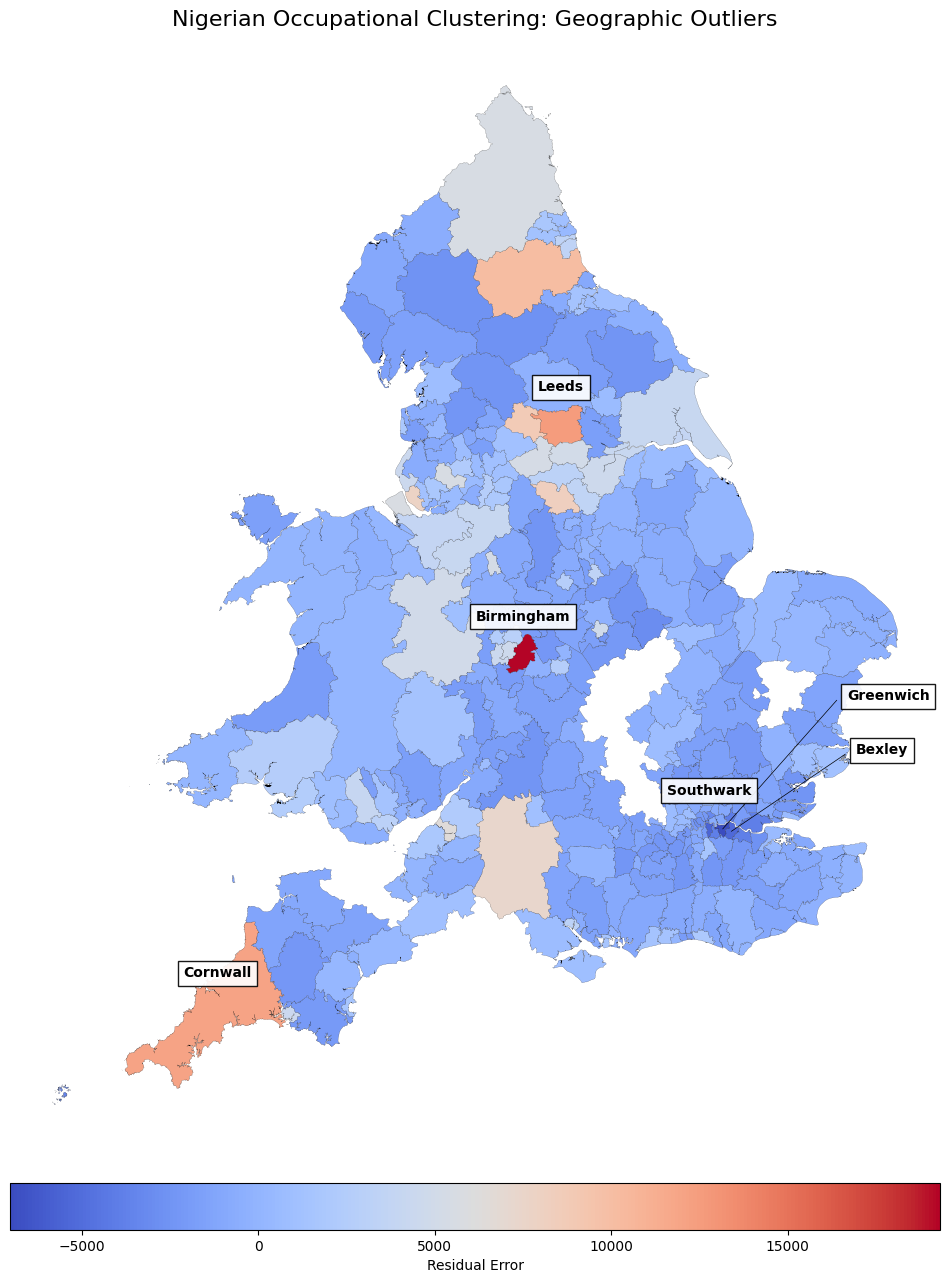

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


merged_map = uk_map.merge(df_sec2, left_on='LAD13CD', right_on='geo_code')
top_outliers = merged_map.sort_values('residual', ascending=False)

to_label = pd.concat([top_outliers.head(3), top_outliers.tail(3)])


fig, ax = plt.subplots(1, 1, figsize=(12, 18))
merged_map.plot(column='residual', cmap='coolwarm', legend=True, ax=ax,
                edgecolor='black', linewidth=0.1,
                legend_kwds={'label': "Residual Error", 'orientation': "horizontal", 'pad': 0.02})


for i, (idx, row) in enumerate(to_label.iterrows()):
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    label = row['area_name']
    
    
    if x > 0 and y < 52:
        
        ax.text(x + 1.2, y + (i * 0.15), label, fontsize=10, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'))
        
        ax.plot([x, x + 1.1], [y, y + (i * 0.15)], color='black', linewidth=0.5)
    else:
        ax.text(x, y + 0.2, label, fontsize=10, fontweight='bold', ha='center',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'))

ax.set_title("Nigerian Occupational Clustering: Geographic Outliers", fontsize=16)
ax.axis('off')
plt.show()

# High-Concentration Outliers (Red/Orange)
Birmingham represents a major hub where the Nigerian community is disproportionately employed in care work.

Leeds shows a heavy sectoral skew. The positive residual confirms that the "Care Work Trap" is a persistent trend in large Northern and Midlands urban centers.

Cornwall exhibits an extreme concentration despite a lower total Nigerian population.

# Diversified Hubs (Blue)
Southwark & Greenwich, at the Core of London, show high professional diversification, despite having some of the largest Nigerian populations in the UK

Bexley suggests that even in London's outer boroughs, the community maintains a more balanced occupational profile compared to the Midlands or the North.